# 1.0 Coefficient of variation

- Coefficient of Variation (CV) is a standardized measure of dispersion that expresses the standard deviation as a percentage of the mean. It lets you compare variability across datasets with different units or scales.

#### Q: "Why not just use standard deviation?"

A: "Standard deviation is absolute — it doesn't account for scale. If one dataset has values in the thousands and another in single digits, their SDs aren't comparable. CV normalizes by the mean, so we compare relative spread. It's like asking: 'How big is the noise compared to the signal?'"

In [2]:
import numpy as np
def coe_variation(input) -> float:
  arr =  np.array(input)
  mean_ = np.mean(arr)
  std = np.std(arr)
  return (std/mean_)  * 100

machine_a = [10.1, 9.9, 10.0, 10.2, 9.8]
machine_b = [10.5, 9.0, 11.0, 8.5, 11.5]

print(f"coe_var_mch_a: {coe_variation(machine_a):.2f}")
print(f"coe_var_mch_b: {coe_variation(machine_b):.2f}")

coe_var_mch_a: 1.41
coe_var_mch_b: 11.46


- CV is a powerful tool to test the variablity of 2 different datasets, or for the data analysis!

# 2.0 Covariance vs Correlation
- Covariance measures the direction of linear relationship between two variables (but is scale-dependent).

- Correlation measures both direction and strength of linear relationship, standardized to [-1, +1] (scale-independent).
---------------------------
$
\mathrm{Cov}(X,Y)
=
\frac{1}{n-1}
\sum_{i=1}^{n}
(x_i - \bar{x})(y_i - \bar{y})
$

---------------------------

$r
=
\frac{
\sum_{i=1}^{n}
(x_i - \bar{x})(y_i - \bar{y})
}
{
\sqrt{
\sum_{i=1}^{n}(x_i - \bar{x})^2
}
\sqrt{
\sum_{i=1}^{n}(y_i - \bar{y})^2
}
}$


In [3]:
# finding both values for the datasets
import pandas as pd
import numpy as np

from sklearn.datasets import load_diabetes

data = load_diabetes()
df = pd.DataFrame(data= data.data, columns=data.feature_names)
df['target'] = data.target

print(df.cov())

             age       sex       bmi        bp        s1        s2        s3  \
age     0.002268  0.000394  0.000420  0.000761  0.000590  0.000497 -0.000170   
sex     0.000394  0.002268  0.000200  0.000547  0.000080  0.000323 -0.000860   
bmi     0.000420  0.000200  0.002268  0.000897  0.000566  0.000592 -0.000832   
bp      0.000761  0.000547  0.000897  0.002268  0.000550  0.000421 -0.000405   
s1      0.000590  0.000080  0.000566  0.000550  0.002268  0.002033  0.000117   
s2      0.000497  0.000323  0.000592  0.000421  0.002033  0.002268 -0.000445   
s3     -0.000170 -0.000860 -0.000832 -0.000405  0.000117 -0.000445  0.002268   
s4      0.000462  0.000753  0.000938  0.000584  0.001229  0.001496 -0.001675   
s5      0.000614  0.000340  0.001012  0.000892  0.001169  0.000722 -0.000904   
s6      0.000684  0.000472  0.000881  0.000885  0.000739  0.000659 -0.000621   
target  0.689758  0.158085  2.152914  1.620722  0.778355  0.638967 -1.449309   

              s4        s5        s6   

In [4]:
df.corr()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731,0.187889
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133,0.043062
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680,0.586450
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430,0.441482
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717,0.212022
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600,0.174054
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697,-0.394789
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212,0.430453
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669,0.565883
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000,0.382483


# 3.0 Normal Distributions - Gaussian Distributions

-  The normal distribution is symatrrical where the data follows the distribution in mean=median=mode format & 68.26% of data is within 1 std , 95.44 % within 2std, 99.72 within 3std
- most values are around the mean
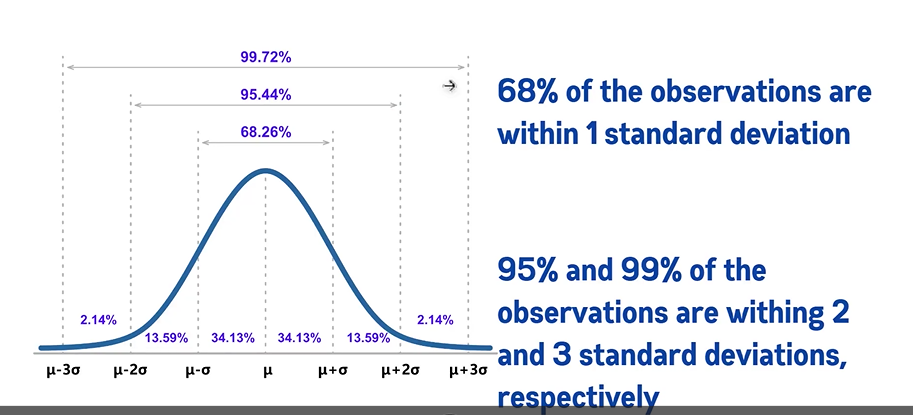

methods to check
- hist plot,
- Q-Q plot
- shapiro test

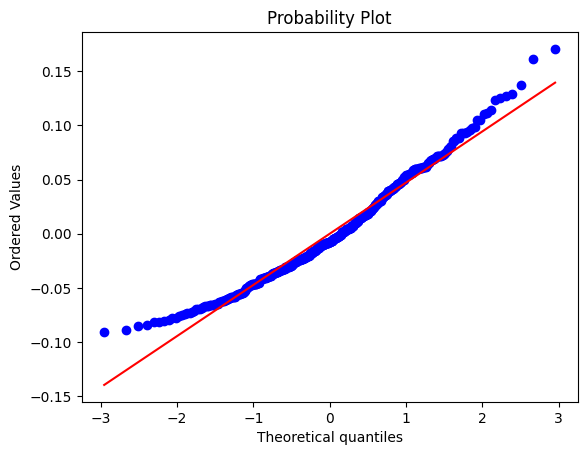

In [5]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(df['bmi'], dist="norm", plot=plt)
plt.show()

In [6]:
from scipy.stats import shapiro
stats, p = shapiro(df['bmi'])
p

np.float64(2.519594252400323e-07)

# 4.0 Confidence intervals
Imagine you're tasting soup.

You take one spoonful (your sample) to guess how salty the whole pot (population) is.

The sample mean = saltiness of your spoon.

The standard deviation = how much saltiness varies between spoonfuls in your sample.

The standard error of the mean (SEM) = how much your guess of the whole pot's saltiness would wiggle if you took many different spoons.

The confidence interval (CI) = a range around your spoon's saltiness where you're pretty sure the true pot saltiness lives.

🔑 Core intuition:
SEM shrinks as you take more spoons (bigger sample → more precise guess).
CI = Your guess ± a "fudge factor" × SEM.
The "fudge factor" depends on how confident you want to be (95%? 99%) and how many spoons you took.

SD answers: "How spread out is my data?"

SEM answers: "How precise is my estimate of the mean?"

CI answers: "What range of true means are compatible with my data?"

> ## CI: The method used to construct this interval captures the true mean 95% of the time in repeated sampling.

In [7]:
import pandas as pd
import numpy as np
import scipy.stats as st
import math as m
import statsmodels.stats.api as sm


# Calculate the 95% Confidence Interval for the mean of 'bmi'
bmi_data = df['bmi']

# Method 1: Using scipy.stats.t.interval (for smaller samples or unknown population standard deviation)
confidence_level = 0.95
data_mean = np.mean(bmi_data)
data_std = np.std(bmi_data, ddof=1) # ddof=1 for sample standard deviation
standard_error = data_std / np.sqrt(len(bmi_data))

ci_scipy = st.t.interval(confidence_level, len(bmi_data)-1, loc=data_mean, scale=standard_error)
print(f"95% Confidence Interval (scipy.stats.t.interval): {ci_scipy}")

# Method 2: Using statsmodels.stats.api.DescrStatsW (often preferred for more comprehensive stats)
descr = sm.DescrStatsW(bmi_data)
ci_statsmodels = descr.tconfint_mean(alpha=1-confidence_level)
print(f"95% Confidence Interval (statsmodels.stats.api.DescrStatsW): {ci_statsmodels}")

# Example with a different confidence level (e.g., 99%)
confidence_level_99 = 0.99
ci_99_scipy = st.t.interval(confidence_level_99, len(bmi_data)-1, loc=data_mean, scale=standard_error)
print(f"99% Confidence Interval (scipy.stats.t.interval): {ci_99_scipy}")

ci_99_statsmodels = descr.tconfint_mean(alpha=1-confidence_level_99)
print(f"99% Confidence Interval (statsmodels.stats.api.DescrStatsW): {ci_99_statsmodels}")

95% Confidence Interval (scipy.stats.t.interval): (np.float64(-0.004451549462177968), np.float64(0.0044515494621775184))
95% Confidence Interval (statsmodels.stats.api.DescrStatsW): (np.float64(-0.004451549462177967), np.float64(0.004451549462177519))
99% Confidence Interval (scipy.stats.t.interval): (np.float64(-0.0058596266497539466), np.float64(0.005859626649753497))
99% Confidence Interval (statsmodels.stats.api.DescrStatsW): (np.float64(-0.005859626649753946), np.float64(0.005859626649753498))


# 5.0 SEM(Standard Error of Mean)

Topic: Standard Error of the Mean (SEM)

> **Professional Context:** In A/B testing or model evaluation, we don't just care about the mean; we care about how much that mean would jump around if we ran the experiment again. The SEM quantifies this "jitter."

In [8]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [9]:
print(f"Population mean: {df.sex.mean()}")
print(f"sem for sex col: {df['sex'].std()/m.sqrt(df.sex.count())}")
print(f"scipy_method: {st.sem(df.sex)}")
print("----------"*12)
print("SEM: Tells you that if you took 100 different samples of 50 students and calculated the average for each,\n those averages would cluster very tightly around the true school average. Your estimate is precise.(relies on CLT Theorem)")

Population mean: 1.2307902309192911e-17
sem for sex col: 0.002265007115021409
scipy_method: 0.0022650071150214024
------------------------------------------------------------------------------------------------------------------------
SEM: Tells you that if you took 100 different samples of 50 students and calculated the average for each,
 those averages would cluster very tightly around the true school average. Your estimate is precise.(relies on CLT Theorem)


# 6.0 Z_score & Standardization
**Standard Deviation (σ or s)**
Measures the spread of the entire dataset around the mean.

Population formula:
$$
\sigma = \sqrt{\frac{\sum (x_i - \mu)^2}{N}}
$$

Sample formula:
$$
s = \sqrt{\frac{\sum (x_i - \bar{x})^2}{n - 1}}
$$

---

**Z-score (Z)**
Measures how many standard deviations a specific value is from the mean.

$$
Z = \frac{x - \mu}{\sigma}
$$

---

**In one line:**
Standard deviation measures overall variability;
Z-score measures relative position within that variability.



In [10]:
from sklearn.preprocessing import StandardScaler

# Assuming df is already loaded
bmi_data = df['bmi']

# Standardization (Z-score normalization)
scaler = StandardScaler()
# The scaler expects a 2D array, so we reshape bmi_data
bmi_scaled = scaler.fit_transform(bmi_data.values.reshape(-1, 1))

print("Original BMI data (first 5 values):")
print(bmi_data.head())
print("\nStandardized BMI data (first 5 values) - Z-scores:")
print(bmi_scaled[:5])

# Verify mean and standard deviation of the standardized data
print(f"\nMean of standardized BMI: {bmi_scaled.mean():.2f}")
print(f"Standard deviation of standardized BMI: {bmi_scaled.std():.2f}")

Original BMI data (first 5 values):
0    0.061696
1   -0.051474
2    0.044451
3   -0.011595
4   -0.036385
Name: bmi, dtype: float64

Standardized BMI data (first 5 values) - Z-scores:
[[ 1.29708846]
 [-1.08218016]
 [ 0.93453324]
 [-0.24377122]
 [-0.76494435]]

Mean of standardized BMI: -0.00
Standard deviation of standardized BMI: 1.00


# 7.0 Confidence Level

- Confidence level is a statiscal measure that state how sure one can be that statistical conclusion is accurate,
- common confidence level is 95 %, that there are 95 % chance result is accurate.

- Mostly used for CI and Hypothesis Testing.

Confidence Interval is likely range that true population mean is likely found between these range, with some level of certainity.

## CI width determined by:
- Confidence Level
- SEM

In [11]:
cl_levels = [0.90, 0.95, 0.99]

for level in cl_levels:
    ci_scipy = st.t.interval(level, len(bmi_data)-1, loc=data_mean, scale=standard_error)
    print(f"{int(level*100)}% Confidence Interval (scipy.stats.t.interval): {ci_scipy}")

90% Confidence Interval (scipy.stats.t.interval): (np.float64(-0.003733447920330919), np.float64(0.003733447920330468))
95% Confidence Interval (scipy.stats.t.interval): (np.float64(-0.004451549462177968), np.float64(0.0044515494621775184))
99% Confidence Interval (scipy.stats.t.interval): (np.float64(-0.0058596266497539466), np.float64(0.005859626649753497))
